# Quantifying Two-Qubit Entanglement from Pauli Expectation Values Using a Two-Stage Autoencoder–Regressor Architecture

Quantum entanglement is a fundamental resource in quantum information processing, yet its experimental quantification through full two-qubit state tomography remains costly and noise-sensitive. 
Following the methodology proposed by Pan *et al.* and the project framework of DTU’s 02456 Deep Learning course, this notebook implements a complete machine-learning pipeline that predicts Wootters’ concurrence, the standard entanglement monotone for two-qubit states, directly from nine Pauli–Pauli expectation values.

To achieve this, we generate a diverse dataset of **100,000 two-qubit density matrices**, compute their nine measurable correlations ⟨σᵢ ⊗ σⱼ⟩, and then train a two-stage architecture:

1. **Autoencoder (unsupervised)**: compresses the nine expectation values into a 3-dimensional latent representation, reconstructing clean data even when noise or missing operators are present.  
2. **Concurrence Regressor (supervised)**: uses the frozen encoder and learns to predict concurrence from the learned latent space.

This staged setup separates representation learning from supervised prediction, enabling a compact, noise-resistant encoding of quantum correlations while maintaining strong predictive accuracy. The notebook faithfully reproduces the experimental protocol, dataset, architectures, and performance metrics described in the accompanying report.

---

# Table of Contents

### 1. Dataset Generation
- Generation of 100,000 two-qubit density matrices  
- Calculation of the nine Pauli–Pauli measurement operators  
- Extraction of measurement features (expectation values)  
- Addition of Gaussian noise  
- Masking operators (reducing from 9 to 6 where required)  
- Train / validation / test split  
- PyTorch dataset objects and dataloaders  

### 2. Autoencoder
- Autoencoder architecture (9 → 5 → 3 → 5 → 9)  
- Specification of the latent dimension  
- Training and validation functions (1-epoch loop)  
- Full autoencoder training (50 epochs)

### 3. Concurrence Regressor
- Construction of the regressor with the frozen encoder  
- Training and validation functions (1-epoch loop)  
- Full regressor training (100 epochs)  
- Evaluation on the test set  

### 4. Visualizations
- Training curves for autoencoder and regressor  
- Predicted vs. true concurrence scatterplots  
- Additional plots supporting noise experiments and reconstruction quality  


# Dataset Generation

In [8]:
import numpy as np
from toqito.state_props import concurrence
from toqito.matrices import pauli
from toqito.rand import random_density_matrix, random_state_vector

In [9]:
def generate_random_state():
    """Generates a 4x4 random (mixed) density matrix."""
    return random_density_matrix(dim=4)

def generate_separable_state():
    """
    Generates a 4x4 random separable state.
    We create two random 1-qubit states (2x2) and combine them.
    rho_sep = rho_A (tensor) rho_B
    """
    rho_A = random_density_matrix(dim=2)
    rho_B = random_density_matrix(dim=2)
    return np.kron(rho_A, rho_B)

def generate_pure_state():
    """
    Generates a 4x4 random pure state.
    We get a random state vector |psi> and compute rho = |psi><psi|.
    """
    psi_vec = random_state_vector(dim=4)
    rho_pure = psi_vec @ psi_vec.conj().T
    return rho_pure

### Generation of 100,000 two-qubit density matrices from which:

40,000 are random mixed states

40,000 are separable states constructed ast kronecker products

20,000 are random pure states

In [10]:
N_RANDOM = 40000
N_SEPARABLE = 40000
N_PURE = 20000

all_density_matrices = []

# Generate datasets
print("Generating random states")
for _ in range(N_RANDOM):
    all_density_matrices.append(generate_random_state())

print("Generating separable states")
for _ in range(N_SEPARABLE):
    all_density_matrices.append(generate_separable_state())

print("Generating pure states")
for _ in range(N_PURE):
    all_density_matrices.append(generate_pure_state())

np.random.shuffle(all_density_matrices)

# Convert the list of matrices into a single NumPy array
dataset_rho = np.array(all_density_matrices)

Generating random states
Generating separable states
Generating pure states


### Calculating the 9 measurement operators that will help obtain the 9 expectation values

In [11]:
# Pauli matrices
sigma_x = pauli(1)
sigma_y = pauli(2)
sigma_z = pauli(3)

operators = []
labels = []

pauli_list = [(sigma_x, 'X'), (sigma_y, 'Y'), (sigma_z, 'Z')]

print("Building 9 Measurement Operators")
for p1, name1 in pauli_list:
    for p2, name2 in pauli_list:
        op = np.kron(p1, p2)
        operators.append(op)
        labels.append(name1 + name2)

print("Operators:", labels)
num_samples = len(dataset_rho)
Y_decoder = np.zeros((num_samples, 9))
Y_regressor = np.zeros((num_samples, 1))

Building 9 Measurement Operators
Operators: ['XX', 'XY', 'XZ', 'YX', 'YY', 'YZ', 'ZX', 'ZY', 'ZZ']


### Calculating Features

True concurrence: Obtained by the concurrence function from toqito library with the density matrix.

9 Expectation Values: Does a matrix mutliplication with the density matrix and one of the operators, then obtains the trace, repeats for each of the 9 operators until the 9 expectation values are obtained

In [12]:
print(f"\nCalculating features for {num_samples} states")

for i in range(num_samples):
    rho = dataset_rho[i]
    
    # Concurrence (Will be our output of the regressor head)
    # toquito can return a complex, so we change to real
    conc = concurrence(rho)
    Y_regressor[i] = float(np.real(conc))
    
    for j, op in enumerate(operators):
        expectation_val = np.trace(rho @ op).real
        Y_decoder[i, j] = expectation_val

print(f"True Concurrence: {Y_regressor[0]}")
print(f"9 Pauli Values:   {Y_decoder[0]}")

X_encoder = Y_decoder.copy() 


Calculating features for 100000 states
True Concurrence: [0.]
9 Pauli Values:   [ 0.11943021  0.11758423 -0.05536724 -0.16164294 -0.15914449  0.07493685
 -0.31992075 -0.31497586  0.14831365]


### Noise

The code adds Gaussian noise to each input of encoder_X

In [13]:
NOISE = False
noise_level = 0.05
# Adding Noise to X_encoder

if NOISE:
    print(f'\nAdding {noise_level} noise to encoder input')
    for i in range(X_encoder.shape[0]):
        X_encoder[i] = X_encoder[i] + np.random.normal(0, noise_level, 9)
    print("Before Noise:", Y_decoder[0])
    print("After  Noise:", X_encoder[0])

### Masks the 9 operators to 6, making the Encoder F1 from F2

In [14]:
F1 = False
if F1:
    print('\nApplying F1 masking to encoder input')
    mask = np.array([1,1,1,0,1,1,0,0,1])  
    for i in range(X_encoder.shape[0]):
        X_encoder[i] = X_encoder[i] * mask
        
    print("Before Masking:", Y_decoder[0])
    print("After  Masking:", X_encoder[0])

### Dataset split into Train / Val / Test

The data is divided into 70% training, 20% validation and 10% testing

In [15]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, Y_dec_train_val, Y_dec_test, Y_reg_train_val, Y_reg_test = train_test_split(
    X_encoder, Y_decoder, Y_regressor, 
    test_size=0.10, 
    random_state=42
)

X_train, X_val, Y_dec_train, Y_dec_val, Y_reg_train, Y_reg_val = train_test_split(
    X_train_val, Y_dec_train_val, Y_reg_train_val, 
    test_size=0.22222, # 0.22222 * 0.90 = 0.20
    random_state=42
)

# Train 70%, Val 20%, Test 10%

print("\n Data Split Complete")
print(f"TRAIN set: {X_train.shape[0]} samples")
print(f"VAL set:   {X_val.shape[0]} samples")
print(f"TEST set:  {X_test.shape[0]} samples")


 Data Split Complete
TRAIN set: 70000 samples
VAL set:   20000 samples
TEST set:  10000 samples


### PyTorch dataset and dataloaders for training, validation and testing

Using a batch size of 64

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class QuantumDataset(Dataset):
    def __init__(self, X_enc, Y_dec, Y_reg):
        self.X_enc = torch.tensor(X_enc, dtype=torch.float32) # 9 Pauli expectation values for encoder input
        self.Y_dec = torch.tensor(Y_dec, dtype=torch.float32) # 9 Pauli expectation values for decoder output
        self.Y_reg = torch.tensor(Y_reg, dtype=torch.float32) # Concurrence values

    def __len__(self):
        return len(self.Y_dec)

    def __getitem__(self, idx):
        return self.X_enc[idx], self.Y_dec[idx], self.Y_reg[idx]


# Dataloaders
BATCH_SIZE = 64

train_dataset = QuantumDataset(X_train, Y_dec_train, Y_reg_train)
val_dataset   = QuantumDataset(X_val, Y_dec_val, Y_reg_val)
test_dataset  = QuantumDataset(X_test, Y_dec_test, Y_reg_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Autoencoder architecture

The encoder compresses the 9 dimensional input data into a 3 dimensional latent space and then reconstructs it. Returns both the encoder and decoder output, the encoder is used later for the regression head.

In [17]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=9, latent_dim=3):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 5),
            nn.ReLU(),
            nn.Linear(5, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 5),
            nn.ReLU(),
            nn.Linear(5, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat

### Latent dimension for the autoencoder

In [18]:
LATENT_DIM = 3  #! Dimensionality of bottleneck layer for autoencoder
autoencoder = AutoEncoder(input_dim=9, latent_dim=LATENT_DIM)

optimizer_ae = optim.Adam(autoencoder.parameters(), lr=0.001)
loss_function_ae = nn.MSELoss()

### Autoencoder training and validation functions for 1 epoch

In [19]:
def train_epoch_ae(model, data_loader, optimizer, loss_fn):
    """Train autoencoder for one epoch"""
    model.train()
    train_loss = 0.0
    
    for x_pauli, y_pauli_vals, _ in data_loader:
        # Forward pass
        z, pauli_reconstructed = model(x_pauli)
        
        # Loss
        loss = loss_fn(pauli_reconstructed, y_pauli_vals)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # Avg loss per batch
    return train_loss / len(data_loader)

def validate_epoch_ae(model, data_loader, loss_fn):
    """Validate autoencoder for one epoch"""
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for x_pauli, y_pauli_vals, _ in data_loader:
            z, pauli_reconstructed = model(x_pauli)
            loss = loss_fn(pauli_reconstructed, y_pauli_vals)
            val_loss += loss.item()
    
    # Avg loss per batch 
    return val_loss / len(data_loader)

### Training the autoencoder with 50 epochs

In [20]:
print("TRAINING AUTOENCODER")

# Training loop for autoencoder
num_epochs_ae = 50 #! Select number of epochs
train_losses_ae = []
val_losses_ae = []

for epoch in range(num_epochs_ae):
    train_loss = train_epoch_ae(autoencoder, train_loader, optimizer_ae, loss_function_ae)
    val_loss = validate_epoch_ae(autoencoder, val_loader, loss_function_ae)
    
    train_losses_ae.append(train_loss)
    val_losses_ae.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_ae}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("Autoencoder trained")

TRAINING AUTOENCODER
Epoch [10/50] - Train Loss: 0.033738, Val Loss: 0.033458
Epoch [20/50] - Train Loss: 0.032783, Val Loss: 0.032489
Epoch [30/50] - Train Loss: 0.032612, Val Loss: 0.032340
Epoch [40/50] - Train Loss: 0.032574, Val Loss: 0.032273
Epoch [50/50] - Train Loss: 0.032504, Val Loss: 0.032211
Autoencoder trained


# Concurrence Regressor

### Concurrence regressor using the frozen encoder

This model predicts the concurrence usign the latent space learned by the autoencoder's encoder

In [21]:
class ConcurrenceRegressor(nn.Module):
    def __init__(self, encoder, latent_dim=3):
        super(ConcurrenceRegressor, self).__init__()
        self.encoder = encoder
        
        # Freeze encoder weights from previous autoencoder training
        for param in self.encoder.parameters():
            param.requires_grad = False
        
        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
            # nn.Sigmoid()  # Concurrence is between 0 and 1
        )
    
    def forward(self, x):
        z = self.encoder(x)
        # Predict concurrence
        concurrence_pred = self.regressor(z)
        return concurrence_pred

In [22]:
# Create regressor with the trained encoder
regressor_model = ConcurrenceRegressor(autoencoder.encoder, latent_dim=LATENT_DIM)

# New optimizer for regression head only
optimizer_reg = optim.Adam(regressor_model.regressor.parameters(), lr=0.001)
loss_fn_reg = nn.MSELoss()

### Concurrence regressor training and validation for 1 epoch

In [23]:
def train_epoch_reg(model, data_loader, optimizer, loss_fn):
    """Train regressor for one epoch"""
    model.train()
    train_loss = 0.0
    
    for x_pauli, y_pauli_vals, concurrence_true in data_loader:
        # Forward pass
        concurrence_pred = model(x_pauli)
        
        # Loss
        loss = loss_fn(concurrence_pred, concurrence_true)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    return train_loss / len(data_loader)


def validate_epoch_reg(model, data_loader, loss_fn):
    """Validate regressor for one epoch"""
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for x_pauli, y_pauli_vals, concurrence_true in data_loader:
            concurrence_pred = model(x_pauli)
            loss = loss_fn(concurrence_pred, concurrence_true)
            val_loss += loss.item()
    
    return val_loss / len(data_loader)

### Training the regressor with 100 epochs

In [24]:
print("TRAINING CONCURRENCE REGRESSOR")

# Training loop for regressor
num_epochs_reg = 100
train_losses_reg = []
val_losses_reg = []

for epoch in range(num_epochs_reg):
    train_loss = train_epoch_reg(regressor_model, train_loader, optimizer_reg, loss_fn_reg)
    val_loss = validate_epoch_reg(regressor_model, val_loader, loss_fn_reg)
    
    train_losses_reg.append(train_loss)
    val_losses_reg.append(val_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_reg}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("Regressor trained\n")

TRAINING CONCURRENCE REGRESSOR
Epoch [20/100] - Train Loss: 0.007899, Val Loss: 0.008176
Epoch [40/100] - Train Loss: 0.007698, Val Loss: 0.007626
Epoch [60/100] - Train Loss: 0.007642, Val Loss: 0.007495
Epoch [80/100] - Train Loss: 0.007582, Val Loss: 0.007543
Epoch [100/100] - Train Loss: 0.007507, Val Loss: 0.007381
Regressor trained



### Concurrence regressor evaluation with test set

In [25]:
def evaluate_regressor(model, test_loader, loss_fn):
    """Evaluate the regressor on test set"""
    model.eval()
    test_loss = 0.0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for x_pauli, y_pauli_vals, concurrence_true in test_loader:
            concurrence_pred = model(x_pauli)
            loss = loss_fn(concurrence_pred, concurrence_true)
            test_loss += loss.item()
            
            predictions.extend(concurrence_pred.numpy())
            targets.extend(concurrence_true.numpy())
    
    test_loss /= len(test_loader)
    predictions = np.array(predictions)
    targets = np.array(targets)
    
    # Metrics
    mse = np.mean((predictions - targets)**2)
    mae = np.mean(np.abs(predictions - targets))
    rmse = np.sqrt(mse)
    
    print("TEST SET EVALUATION")
    print(f"Test Loss: {test_loss:.6f}")
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
    
    return predictions, targets

predictions, targets = evaluate_regressor(regressor_model, test_loader, loss_fn_reg)

TEST SET EVALUATION
Test Loss: 0.007489
MSE:  0.007509
RMSE: 0.086657
MAE:  0.062297


# Visualizations

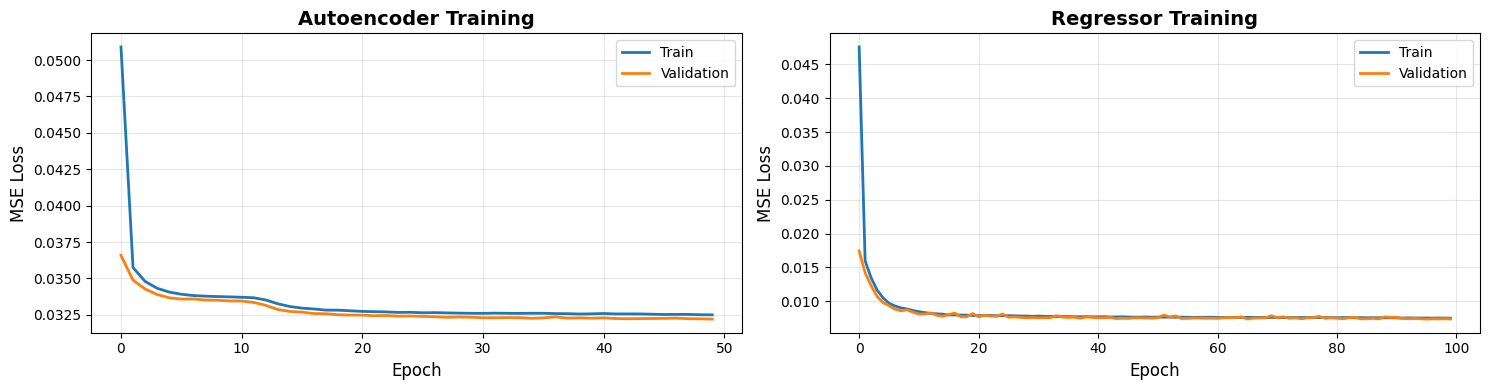

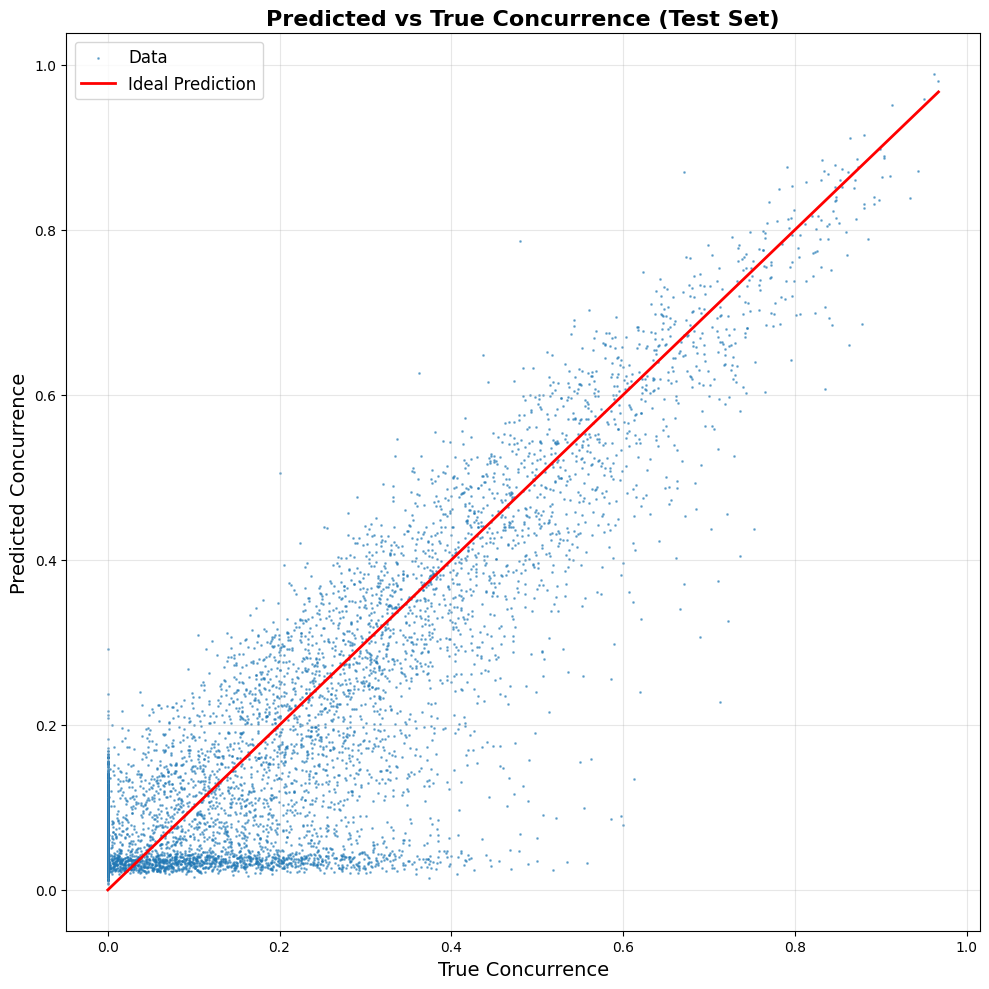

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Autoencoder training curve
axes[0].plot(train_losses_ae, label='Train', linewidth=2)
axes[0].plot(val_losses_ae, label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Autoencoder Training', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Regressor training curve
axes[1].plot(train_losses_reg, label='Train', linewidth=2)
axes[1].plot(val_losses_reg, label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].set_title('Regressor Training', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)

# Scatter plot
plt.figure(figsize=(10, 10))
plt.scatter(targets, predictions, alpha=0.5, s=1, label='Data')
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 
         lw=2, label='Ideal Prediction', color='red')
plt.xlabel('True Concurrence', fontsize=14)
plt.ylabel('Predicted Concurrence', fontsize=14)
plt.title('Predicted vs True Concurrence (Test Set)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('concurrence_prediction.png', dpi=150)